# __Time Series Forecasting__

Time series forecasting is the practice of predicting future values of a quantity measured over time. Unlike standard supervised learning where observations are assumed to be independent, time series data is **ordered in time** — each observation depends on previous ones, and this temporal structure is what makes forecasting both unique and challenging.

**Why do organizations forecast?**
- **Retail**: Predict future sales at SKU level for planning and budgeting
- **Energy**: Forecast electricity demand to balance supply and avoid outages
- **Finance**: Predict stock prices or economic indicators for investment decisions
- **Healthcare**: Anticipate patient volume to allocate hospital resources
- **Tech**: Google forecasts server load to pre-scale infrastructure ahead of peak hours

**How it works:**
1. Collect historical observations over time
2. Analyze trend, seasonality, and cyclical patterns (EDA)
3. Select and train a suitable forecasting model
4. Tune hyperparameters and evaluate predictions against held-out data
5. Deploy the model to produce future predictions

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# __1 <span style='color:#F1C40F'>|</span> Data Collection and Preprocessing__

In this tutorial we forecast monthyl average price of different vegetable types in Nepal

In [78]:
# Load historical daily prices of vegetables and fruits in Nepal
vegetables_prices_df = pd.read_csv(
    "./datasets/nepal_vegetables_prices.csv", parse_dates=["Date"], index_col="Date"
)
print(f"Dataset shape: {vegetables_prices_df.shape}")
print(f"Total unique commodities: {vegetables_prices_df['Commodity'].nunique()}")
vegetables_prices_df.head(10)

Dataset shape: (197161, 6)
Total unique commodities: 132


,SN,Commodity,Unit,Minimum,Maximum,Average
Date,,,,,,
2013-06-16,0,Tomato Big(Nepali),Kg,35.0,40.0,37.5
2013-06-16,1,Tomato Small(Local),Kg,26.0,32.0,29.0
2013-06-16,2,Potato Red,Kg,20.0,21.0,20.5
2013-06-16,3,Potato White,Kg,15.0,16.0,15.5
2013-06-16,4,Onion Dry (Indian),Kg,28.0,30.0,29.0
2013-06-16,5,Carrot(Local),Kg,30.0,35.0,32.5
2013-06-16,6,Cabbage(Local),Kg,6.0,10.0,8.0
2013-06-16,7,Cauli Local,Kg,30.0,35.0,32.5
2013-06-16,8,Raddish Red,Kg,35.0,40.0,37.5


Select 4 commodities for which we want to forecast future price

In [95]:
SELECTED_COMMODITIES = ['Green Peas', "Potato Red", "Onion Dry (Indian)", "Cauli Local"]
print("Selected commodities:")
for c in SELECTED_COMMODITIES:
    print(f"  • {c}")

Selected commodities:
  • Green Peas
  • Potato Red
  • Onion Dry (Indian)
  • Cauli Local


### Preprocessing Pipeline
For each commodity we apply the same cleaning steps:
1. **Handle duplicate timestamps** — in this example we keep only the first observation per date (however, we can also apply other aggregation strategies if it's appropriate)
2. **Reindex** on a complete daily date range to expose hidden gaps as `NaN` (in case of missing timestamps)
3. **Linear interpolation** to fill gaps (suitable for gradually-changing prices)
4. **Monthly resampling** (mean): as our raw data is daily, but we want to forecast monthly average

In [ ]:
def preprocess_commodity(df: pd.DataFrame, commodity: str) -> pd.Series:
    """Full preprocessing pipeline for a single commodity → monthly series."""
    series = df[df["Commodity"] == commodity]["Average"]
    
    # Drop duplicates
    series = series[~series.index.duplicated(keep="first")]
    
    # Fill missing data
    full_range = pd.date_range(start=series.index.min(), end=series.index.max(), freq="D")
    series = series.reindex(full_range).interpolate(method="linear") 
    
    # Monthly resampling
    return series.resample("MS").mean()

commodity_monthly = {c: preprocess_commodity(vegetables_prices_df, c) for c in SELECTED_COMMODITIES}

# Summary
for name, s in commodity_monthly.items():
    print(f"{name:<22} {len(s):>3} months  "
          f"({s.index.min().date()} → {s.index.max().date()})  "
          f"mean={s.mean():.1f} NPR")

Green Peas              96 months  (2013-06-01 → 2021-05-01)  mean=90.6 NPR
Potato Red              96 months  (2013-06-01 → 2021-05-01)  mean=35.1 NPR
Onion Dry (Indian)      96 months  (2013-06-01 → 2021-05-01)  mean=47.6 NPR
Cauli Local             96 months  (2013-06-01 → 2021-05-01)  mean=48.0 NPR


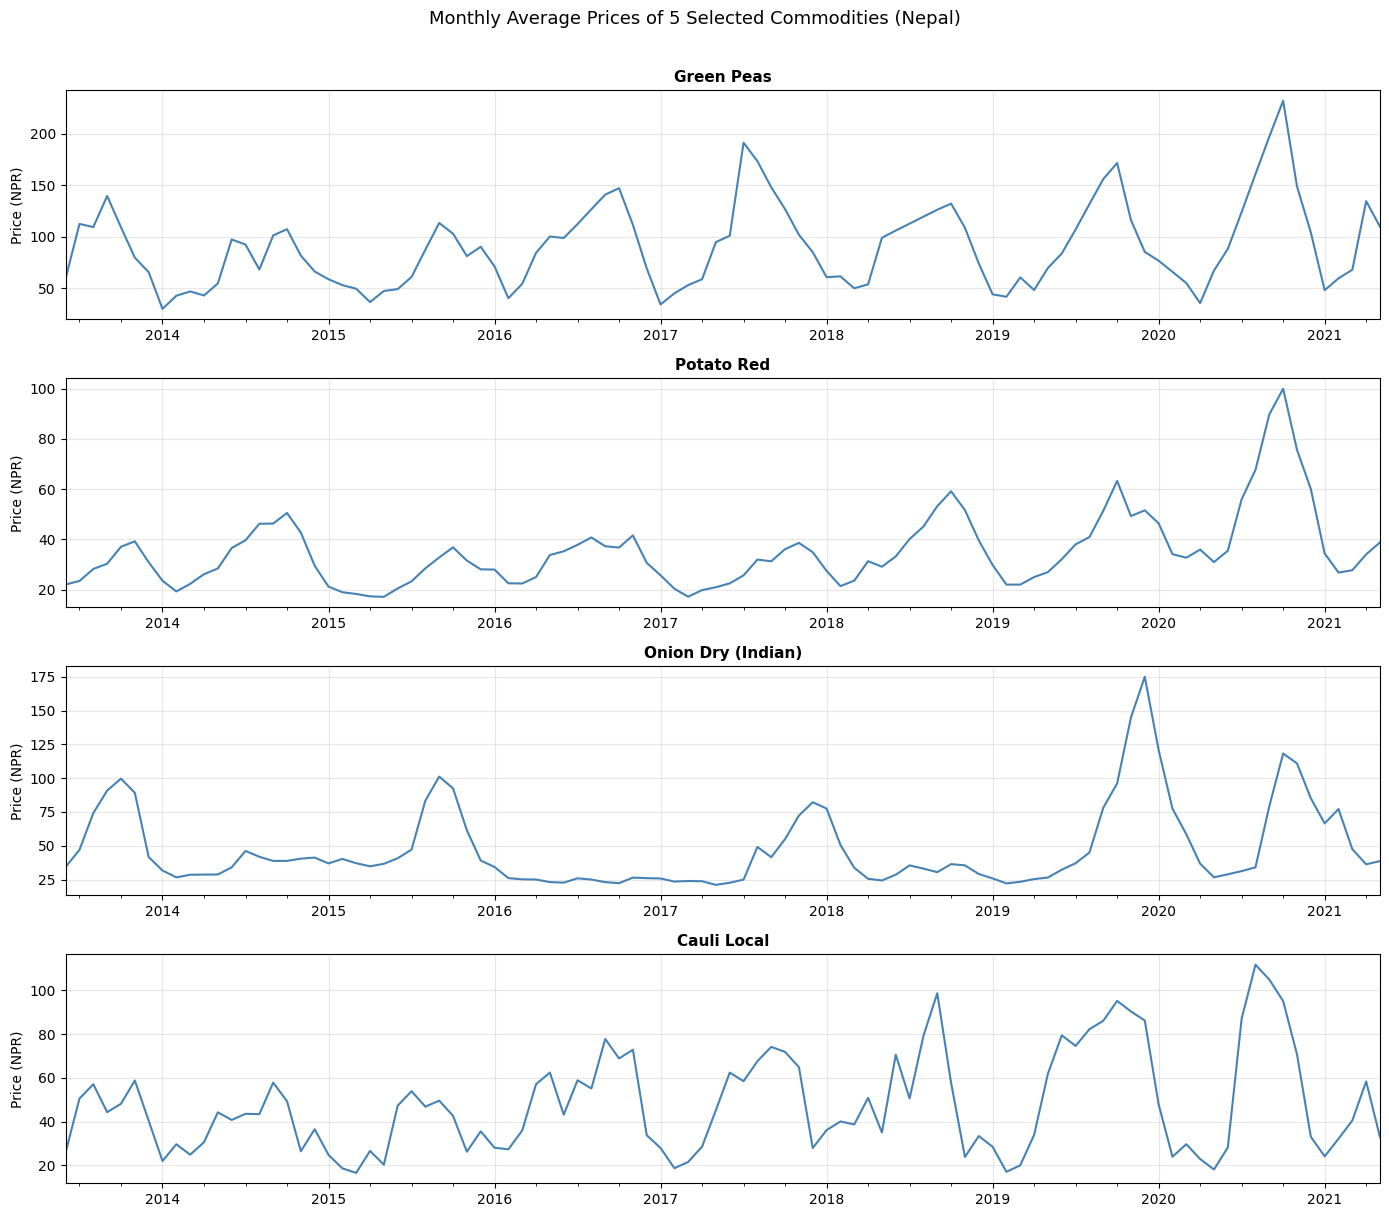

In [97]:
# Visualize all 5 monthly series
fig, axes = plt.subplots(len(SELECTED_COMMODITIES), 1, figsize=(14, 3 * len(SELECTED_COMMODITIES)), sharex=False)

for ax, (name, series) in zip(axes, commodity_monthly.items()):
    series.plot(ax=ax, color="steelblue")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_ylabel("Price (NPR)")
    ax.grid(True, alpha=0.3)

plt.suptitle("Monthly Average Prices of 5 Selected Commodities (Nepal)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# __2 <span style='color:#F1C40F'>|</span> Exploratory Data Analysis (EDA)__
Understanding the structure of each time series is essential before choosing a model. A time series can exhibit four key components:

### __Trend__
The long-term directional movement in the data — an overall increase or decrease in the mean level. Trends can be linear or non-linear and are typically identified visually or via smoothing (e.g., moving average).

### __Seasonality__
Regular, repeating patterns at **fixed intervals** (e.g., every 12 months for annual seasonality). Seasonality is **deterministic** — it occurs predictably at the same time every cycle. Vegetable prices commonly spike in summer/monsoon seasons when supply is constrained.

### __Cyclicity__
Irregular fluctuations driven by economic or environmental cycles. Unlike seasonality, cycles are **not fixed in period** — they can last for varying lengths of time, often years. Cyclicity is hard to model explicitly.

### __Residual (Noise)__
The remaining variation after removing trend, seasonality, and cycles. A well-fitted model should leave residuals that look like **white noise** — random with no remaining structure.

> **Additive**: `y(t) = Trend + Seasonality + Residual` — seasonal amplitude stays roughly constant
> **Multiplicative**: `y(t) = Trend × Seasonality × Residual` — amplitude grows with the trend level

![Time Series properties](./img/time-series-components.png)

### Seasonal Decomposition
We decompose each commodity's series into its structural components using STL-like additive decomposition (period = 12 months).

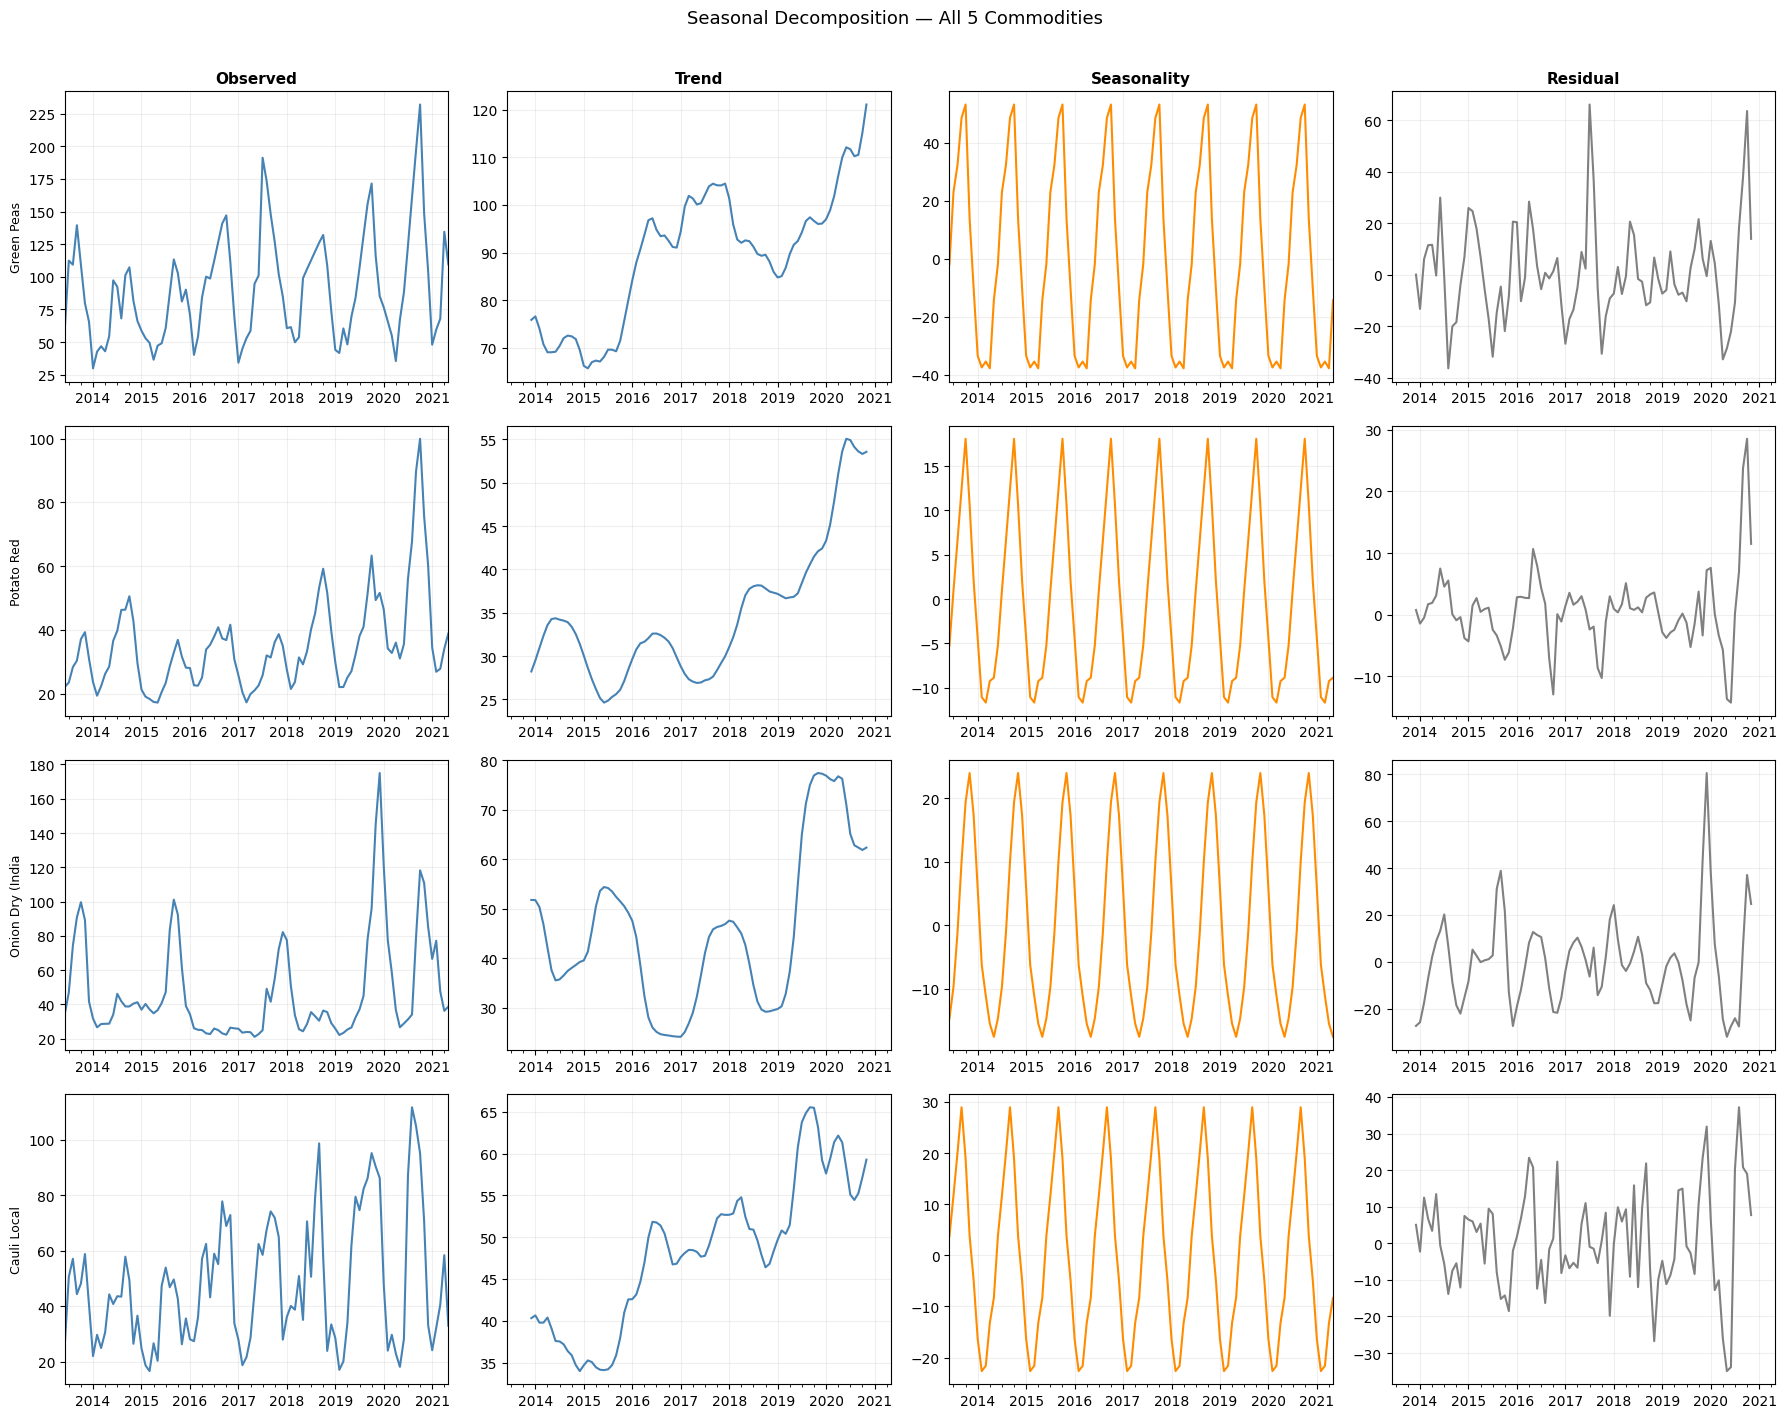

In [98]:
from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(len(SELECTED_COMMODITIES), 4, figsize=(18, 3.5 * len(SELECTED_COMMODITIES)))
component_titles = ["Observed", "Trend", "Seasonality", "Residual"]

for row, (name, series) in enumerate(commodity_monthly.items()):
    decomp = seasonal_decompose(series, model="additive", period=12)
    components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
    for col, (comp, ctitle) in enumerate(zip(components, component_titles)):
        comp.plot(ax=axes[row, col], color="steelblue" if col < 2 else "darkorange" if col == 2 else "gray")
        if row == 0:
            axes[row, col].set_title(ctitle, fontsize=11, fontweight="bold")
        if col == 0:
            axes[row, col].set_ylabel(name[:16], fontsize=9)
        axes[row, col].grid(True, alpha=0.2)

plt.suptitle("Seasonal Decomposition — All 5 Commodities", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Seasonal Patterns by Month and Season
Each commodity has a distinct price rhythm driven by growing seasons, harvesting cycles, and monsoon effects.

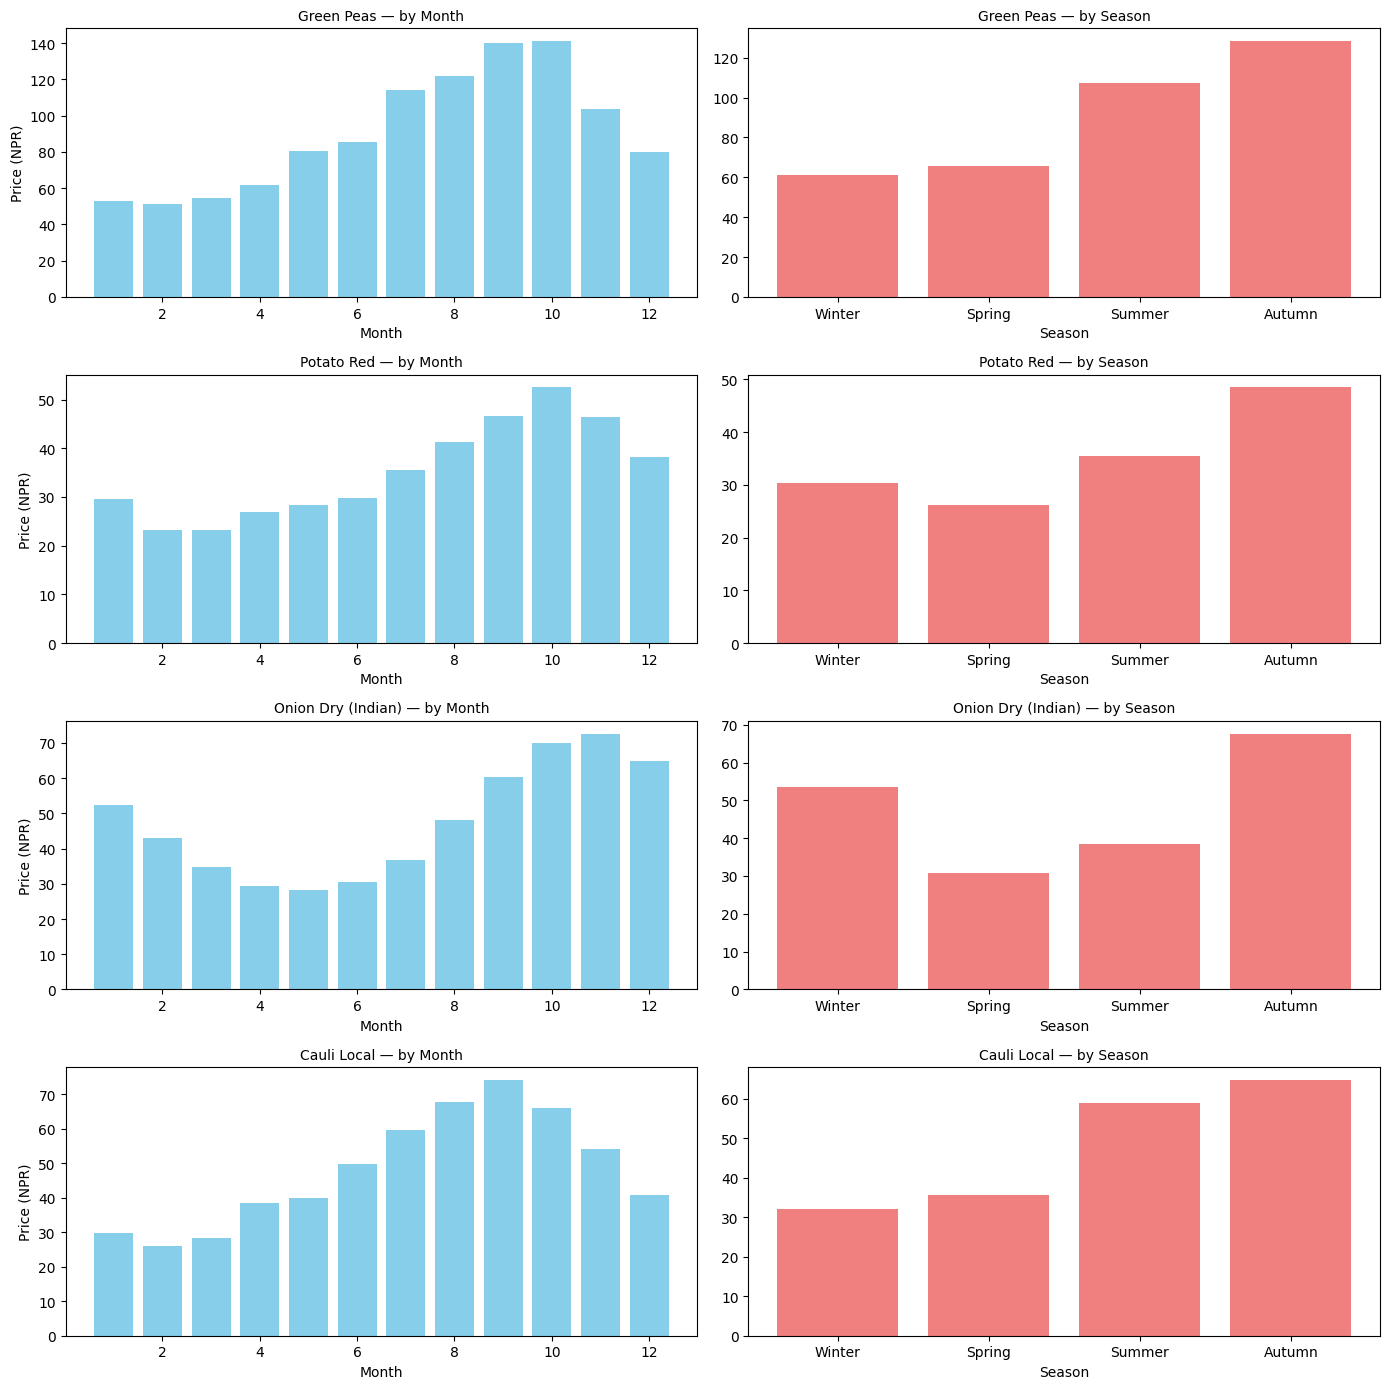

In [99]:
SEASONS = {"Winter": [12, 1, 2], "Spring": [3, 4, 5], "Summer": [6, 7, 8], "Autumn": [9, 10, 11]}

fig, axes = plt.subplots(len(SELECTED_COMMODITIES), 2, figsize=(14, 3.5 * len(SELECTED_COMMODITIES)))

for row, (name, series) in enumerate(commodity_monthly.items()):
    monthly_avg = series.groupby(series.index.month).mean()
    seasonal_avg = {
        season: series[series.index.month.isin(months)].mean()
        for season, months in SEASONS.items()
    }

    axes[row, 0].bar(monthly_avg.index, monthly_avg.values, color="skyblue")
    axes[row, 0].set_title(f"{name} — by Month", fontsize=10)
    axes[row, 0].set_xlabel("Month")
    axes[row, 0].set_ylabel("Price (NPR)")

    axes[row, 1].bar(seasonal_avg.keys(), seasonal_avg.values(), color="lightcoral")
    axes[row, 1].set_title(f"{name} — by Season", fontsize=10)
    axes[row, 1].set_xlabel("Season")

plt.tight_layout()
plt.show()

## __Autocorrelation & Partial Autocorrelation__

Before selecting a model or checking stationarity, we examine the **autocorrelation structure** of each series.

### Autocorrelation Function (ACF)
Measures the **linear correlation between a time series and its own lagged versions**. At lag $k$:
$$\text{ACF}(k) = \text{corr}(y_t,\; y_{t-k})$$

- **Spikes at lags 12, 24, …** → strong annual seasonality
- **Slowly decaying ACF** → trend / long memory → likely **non-stationary**
- **Sharp cutoff after lag q** → suggests MA($q$) component

### Partial Autocorrelation Function (PACF)
Measures the **direct** correlation between $y_t$ and $y_{t-k}$, **removing the influence of all intermediate lags**:
- **Sharp cutoff after lag p** → suggests AR($p$) component
- Less dominated by trend; better captures short-range dependencies

> **ARIMA order selection:** PACF cuts off at $p$ → AR($p$); ACF cuts off at $q$ → MA($q$); both decay slowly → differencing required.

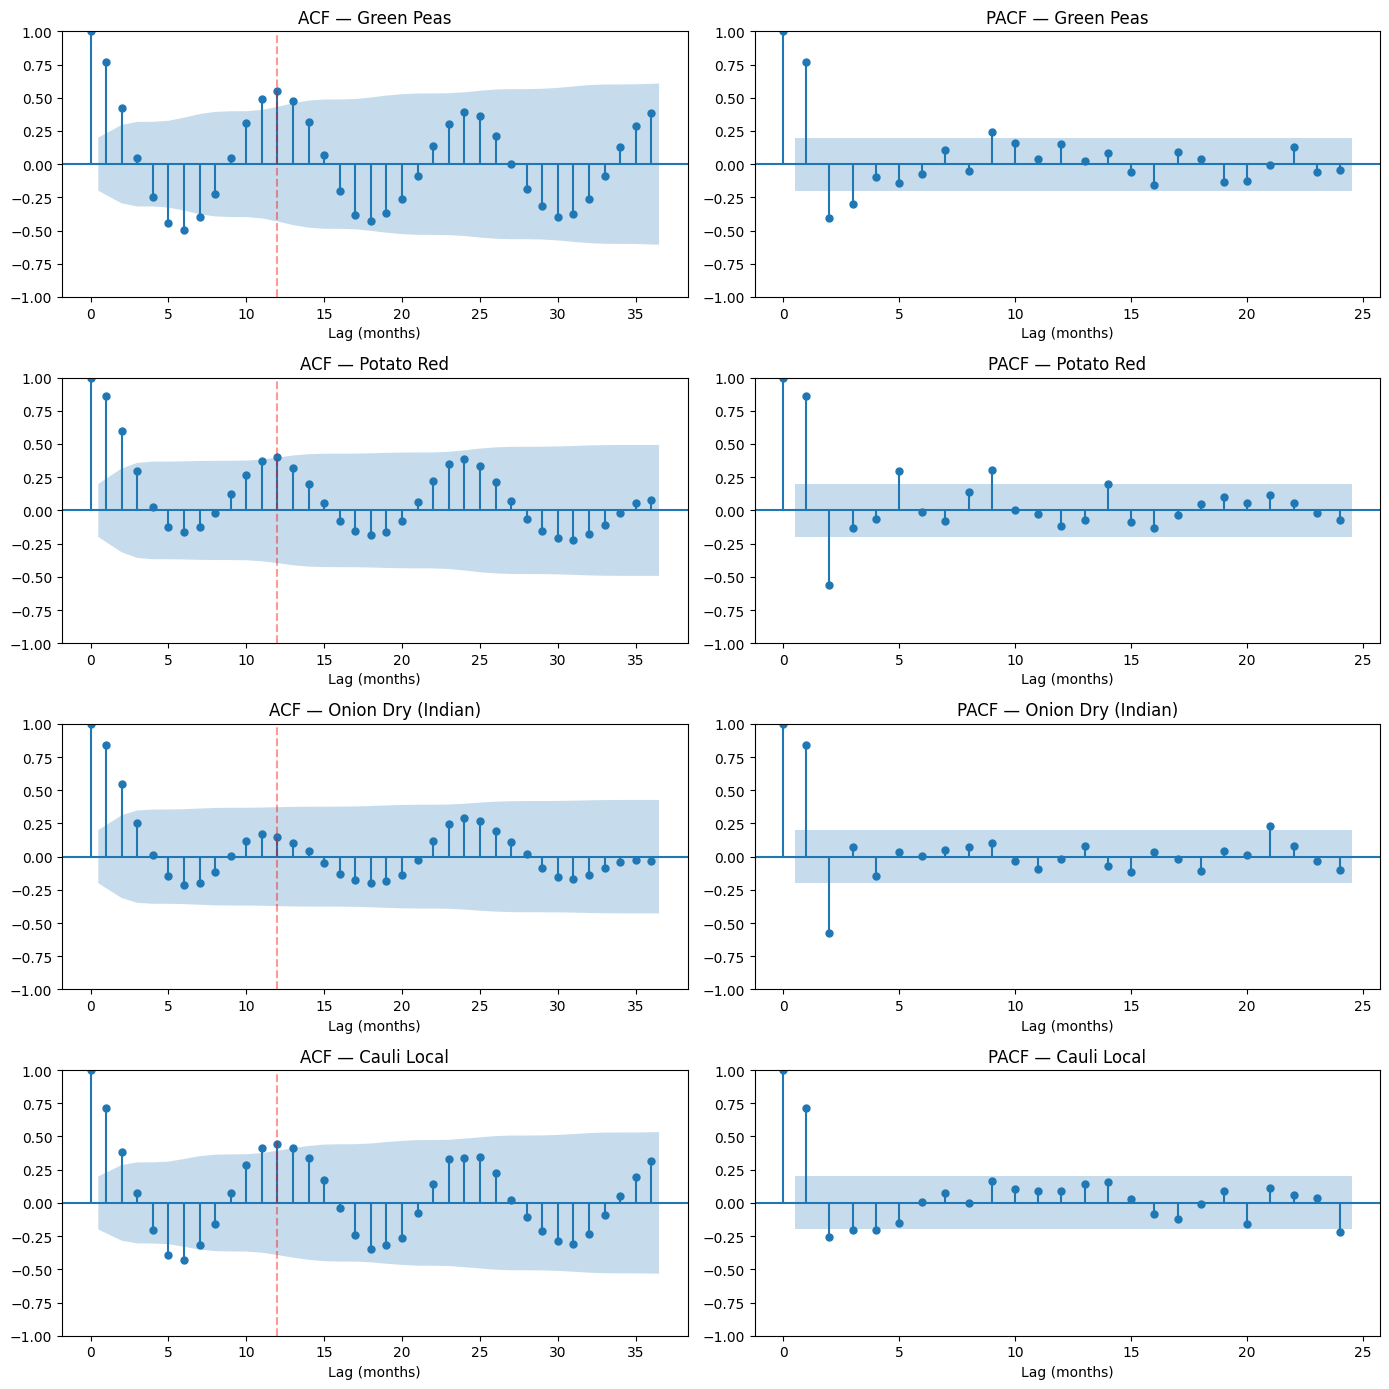

In [138]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(len(SELECTED_COMMODITIES), 2, figsize=(14, 3.5 * len(SELECTED_COMMODITIES)))

for row, (name, series) in enumerate(commodity_monthly.items()):
    plot_acf(series, lags=36, ax=axes[row, 0], title=f"ACF — {name}")
    axes[row, 0].axvline(x=12, color="red", linestyle="--", alpha=0.4)
    axes[row, 0].set_xlabel("Lag (months)")

    plot_pacf(series, lags=24, method="ywm", ax=axes[row, 1], title=f"PACF — {name}")
    axes[row, 1].set_xlabel("Lag (months)")

plt.tight_layout()
plt.show()

## __Stationarity__

The slowly-decaying ACF patterns above are hallmarks of **non-stationary** series — their means drift over time due to trend or long-memory effects.

A time series is **stationary** when its mean, variance, and autocorrelation structure remain **constant over time**. Many classical models (ARIMA family) rely on this assumption.

**Why does it matter?**
ARIMA builds on the mathematics of stationary processes. A non-stationary series causes the model to chase a moving target rather than learning stable patterns. Modern ML models (XGBoost, neural networks) are less sensitive — but stationarity is still a useful diagnostic.

![Time Series Stationarity](./img/stationarity.jpg)

### __Augmented Dickey-Fuller (ADF) Test__
Tests the null hypothesis $H_0$ that the series contains a unit root (non-stationary):
- **p-value < 0.05** → reject $H_0$ → likely **stationary**
- **p-value ≥ 0.05** → fail to reject → likely **non-stationary**

In [86]:
from statsmodels.tsa.stattools import adfuller

def adf_stationarity_test(series: pd.Series) -> dict:
    result = adfuller(series)
    p_value = result[1]
    return {"ADF Statistic": round(result[0], 4), "p-value": round(p_value, 4),
            "Stationary": p_value < 0.05}

adf_results = {name: adf_stationarity_test(s) for name, s in commodity_monthly.items()}
pd.DataFrame(adf_results).T.style.applymap(
    lambda v: "background-color: lightgreen" if v is True else
              "background-color: #ffcccb"    if v is False else "",
    subset=["Stationary"]
)

,ADF Statistic,p-value,Stationary
Green Peas,-0.377900,0.913700,False
Potato Red,-0.181200,0.940700,False
Onion Dry (Indian),-5.173300,0.000000,True


### Making a Non-Stationary Series Stationary: Differencing

$$y_t' = y_t - y_{t-1}$$

First-order differencing removes a linear trend. For seasonal non-stationarity, seasonal differencing at lag $s$ is applied. The ARIMA parameters $d$ and $D$ control this automatically — no need to manually difference before fitting.

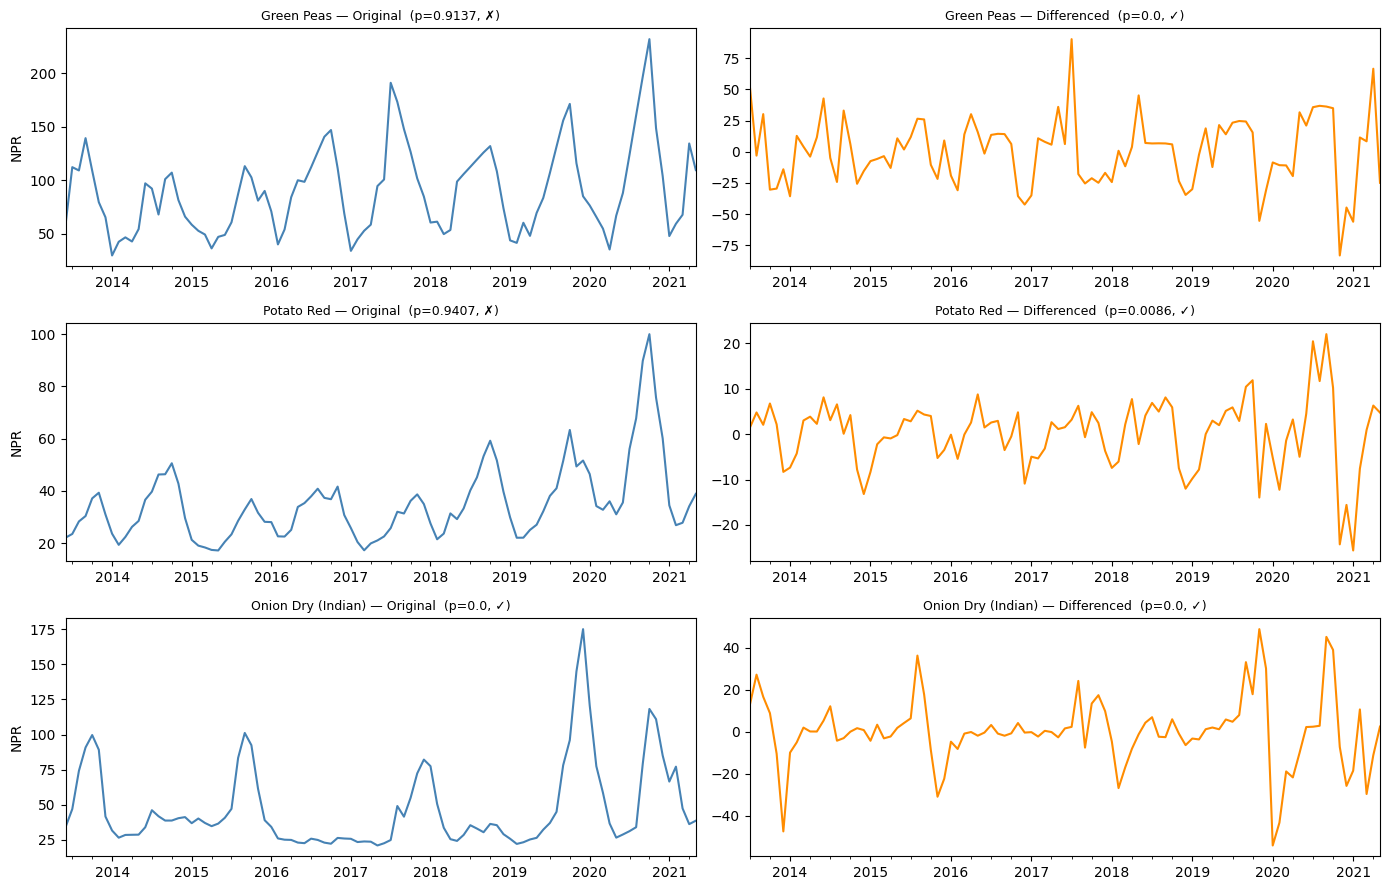

In [88]:
fig, axes = plt.subplots(len(SELECTED_COMMODITIES), 2, figsize=(14, 3 * len(SELECTED_COMMODITIES)))

for row, (name, series) in enumerate(commodity_monthly.items()):
    differenced = series.diff().dropna()
    adf_orig = adf_stationarity_test(series)
    adf_diff = adf_stationarity_test(differenced)

    series.plot(ax=axes[row, 0], color="steelblue")
    axes[row, 0].set_title(
        f"{name} — Original  (p={adf_orig['p-value']}, {'✓' if adf_orig['Stationary'] else '✗'})",
        fontsize=9
    )
    axes[row, 0].set_ylabel("NPR")

    differenced.plot(ax=axes[row, 1], color="darkorange")
    axes[row, 1].set_title(
        f"{name} — Differenced  (p={adf_diff['p-value']}, {'✓' if adf_diff['Stationary'] else '✗'})",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# __3 <span style='color:#F1C40F'>|</span> Key Metrics for Time Series Forecasting__

Evaluating forecast quality requires metrics that capture different aspects of prediction error.

### Point Forecast Metrics

| Metric | Formula | Notes |
|--------|---------|-------|
| **MAE** | $\frac{1}{n}\sum \vert y_t - \hat{y}_t \vert$ | Average absolute error in original units. Robust to outliers. |
| **MSE** | $\frac{1}{n}\sum(y_t - \hat{y}_t)^2$ | Penalizes large errors quadratically. Sensitive to outliers. |
| **RMSE** | $\sqrt{\text{MSE}}$ | Same units as the series. Most common companion to MSE. |
| **MAPE** | $\frac{100}{n}\sum\left \vert \frac{y_t-\hat{y}_t}{y_t}\right \vert$ | Scale-independent %. Undefined near zero. |
| **sMAPE** | $\frac{200}{n}\sum\frac{\vert y_t-\hat{y}_t \vert}{\vert y_t \vert + \vert \hat{y}_t \vert}$ | Symmetric MAPE; more robust near zero. Bounded $[0\%, 200\%]$. |

### Probabilistic Forecast Metrics

**Quantile Loss (Pinball Loss)** at quantile $q$:
$$L_q(y_t, \hat{q}_t) = \max\!\left[\,q\,(y_t - \hat{q}_t),\;(q-1)\,(y_t - \hat{q}_t)\right]$$

- Lower QL → predicted quantile better tracks the true distribution
- QL at $q=0.1$ and $q=0.9$ tests whether the **80% prediction interval** is well-calibrated
- Penalizes over- vs. under-prediction **asymmetrically** based on the quantile level

> **Confidence Interval (CI):** A range within which future values are expected to fall with a given probability. Probabilistic models produce many possible trajectories (samples); the CI is derived from their distribution — e.g., 10th–90th percentile = 80% CI.

# __4 <span style='color:#F1C40F'>|</span> Build Predictive Models__

We use [**Darts**](https://unit8co.github.io/darts/), a unified Python library that provides:
- A **consistent API** across statistical, ML, and deep-learning models
- Built-in **probabilistic forecasting** via `num_samples` — any model can produce a distribution of futures, enabling confidence intervals
- The `TimeSeries` type-aware data structure all Darts models operate on

All 5 models are evaluated on the same **18-month hold-out period** across all 5 commodities, using both point metrics (MAPE, MAE, MSE) and probabilistic metrics (Quantile Loss at 10th and 90th percentiles).

> **Hyperparameter strategy:** We run Bayesian optimization once per model using the **first commodity as reference**, then apply the tuned hyperparameters to all other commodities. This mirrors a practical approach where you tune on a representative series and transfer the configuration.

In [100]:
from darts import TimeSeries
from darts.metrics import mape, mae, mse, mql
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Convert all 5 commodities to darts TimeSeries
commodity_ts = {name: TimeSeries.from_series(s, freq="MS") for name, s in commodity_monthly.items()}

TEST_SIZE = 18  # 18-month forecast horizon
train_splits = {name: ts[:-TEST_SIZE] for name, ts in commodity_ts.items()}
val_splits   = {name: ts[-TEST_SIZE:]  for name, ts in commodity_ts.items()}

# Reference commodity used for hyperparameter tuning
commodity_names = list(commodity_ts.keys())
ref_name  = commodity_names[0]
ref_train = train_splits[ref_name]
ref_val   = val_splits[ref_name]

print(f"Commodities: {commodity_names}")
print(f"Reference for tuning: '{ref_name}'")
print(f"Train / Val sizes: {len(ref_train)} / {len(ref_val)} months")

Commodities: ['Green Peas', 'Potato Red', 'Onion Dry (Indian)', 'Cauli Local']
Reference for tuning: 'Green Peas'
Train / Val sizes: 78 / 18 months


### Utilities: Metrics and Visualization

In [101]:
def calculate_metrics(actual_ts, pred_ts, q_low=0.1, q_high=0.9):
    """Point + probabilistic metrics for a single-commodity forecast."""
    is_prob = pred_ts.n_samples > 1
    median = pred_ts.quantile(0.5) if is_prob else pred_ts
    return {
        "MAPE (%)": round(mape(actual_ts, median), 3),
        "MAE":      round(mae(actual_ts, median), 3),
        "MSE":      round(mse(actual_ts, median), 3),
        f"QL@{q_low}":  round(mql(actual_ts, pred_ts, q=q_low),  3) if is_prob else None,
        f"QL@{q_high}": round(mql(actual_ts, pred_ts, q=q_high), 3) if is_prob else None,
    }


def visualize_multi_forecast(model_name, predictions, q_low=0.1, q_high=0.9):
    """Plot forecasts for all commodities in a stacked subplot figure.

    predictions : dict  {commodity_name -> darts TimeSeries (probabilistic)}
    Returns     : dict  {commodity_name -> metrics dict}
    """
    n = len(predictions)
    fig, axes = plt.subplots(n, 1, figsize=(14, 4.5 * n))
    if n == 1:
        axes = [axes]
    all_metrics = {}

    for ax, (name, pred_ts) in zip(axes, predictions.items()):
        train_ts  = train_splits[name]
        actual_ts = val_splits[name]
        is_prob   = pred_ts.n_samples > 1
        median    = pred_ts.quantile(0.5) if is_prob else pred_ts

        train_ts.to_series().plot(ax=ax, label="Training data", color="steelblue", lw=1.8)
        actual_ts.to_series().plot(ax=ax, label="Actual values", color="green",    lw=1.8)
        median.to_series().plot(   ax=ax, label="Forecast (median)", color="tomato",    lw=1.8)

        if is_prob:
            low  = pred_ts.quantile(q_low).values()[:, 0]
            high = pred_ts.quantile(q_high).values()[:, 0]
            ax.fill_between(
                pred_ts.time_index, low, high,
                alpha=0.25, color="tomato",
                label=f"{int((1 - 2*q_low)*100)}% CI"
            )

        ax.set_title(f"{model_name} — {name}", fontsize=11, fontweight="bold")
        ax.set_ylabel("Price (NPR)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper left", fontsize=8)

        metrics = calculate_metrics(actual_ts, pred_ts, q_low, q_high)
        all_metrics[name] = metrics

        summary = f"MAPE {metrics['MAPE (%)']:.1f}%  |  MAE {metrics['MAE']:.1f}"
        if metrics[f"QL@{q_low}"] is not None:
            summary += f"  |  QL@{q_low} {metrics[f'QL@{q_low}']:.1f}  QL@{q_high} {metrics[f'QL@{q_high}']:.1f}"
        ax.text(0.99, 0.97, summary, transform=ax.transAxes, fontsize=9,
                ha="right", va="top",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray", boxstyle="round,pad=0.4"))

    plt.tight_layout()
    plt.show()
    return all_metrics


---
## __Model 1: SARIMA__
### Architecture
SARIMA (**S**easonal **A**uto**R**egressive **I**ntegrated **M**oving **A**verage) combines three components to handle non-stationary time series with seasonality. It is parameterized as **SARIMA(p, d, q)(P, D, Q, s)**:

| Component | Parameter | Meaning |
|-----------|-----------|---------|
| **AR(p)** | $p$ | Uses the last $p$ values to predict the current one |
| **I(d)** | $d$ | Differences the series $d$ times to achieve stationarity |
| **MA(q)** | $q$ | Uses the last $q$ forecast errors to correct predictions |
| **Seasonal AR(P)** | $P$ | Autoregression at seasonal lags (e.g., 12, 24, ...) |
| **Seasonal I(D)** | $D$ | Seasonal differencing at period $s$ |
| **Seasonal MA(Q)** | $Q$ | Moving average at seasonal lags |
| **Period** | $s$ | Seasonal period (12 for monthly data with annual seasonality) |

### Pros ✅ / Cons ❌
✅ Interpretable parameters · handles trend and seasonality natively · native confidence intervals
❌ Assumes linearity · strictly univariate · slow for large datasets · requires stationarity

In [102]:
from darts.models import ARIMA

def sarima_objective(trial):
    p = trial.suggest_int("p", 0, 3)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 3)
    P = trial.suggest_int("P", 0, 2)
    D = trial.suggest_int("D", 0, 1)
    Q = trial.suggest_int("Q", 0, 2)
    try:
        model = ARIMA(p=p, d=d, q=q, seasonal_order=(P, D, Q, 12))
        model.fit(ref_train)
        pred = model.predict(n=len(ref_val))
        return mape(ref_val, pred)
    except Exception:
        return float("inf")

study_sarima = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_sarima.optimize(sarima_objective, n_trials=20, show_progress_bar=True)
print(f"\nBest MAPE on '{ref_name}': {study_sarima.best_value:.2f}%")
print(f"Best params: {study_sarima.best_params}")

Best trial: 15. Best value: 22.9276: 100%|██████████| 20/20 [02:04<00:00,  6.21s/it]


Best MAPE on 'Green Peas': 22.93%
Best params: {'p': 2, 'd': 0, 'q': 1, 'P': 2, 'D': 1, 'Q': 2}


In [105]:
sarima_predictions = {}
bp = study_sarima.best_params

for name, train_ts in train_splits.items():
    model = ARIMA(p=bp["p"], d=bp["d"], q=bp["q"],
                  seasonal_order=(bp["P"], bp["D"], bp["Q"], 12))
    model.fit(train_ts)
    sarima_predictions[name] = model.predict(n=TEST_SIZE, num_samples=500)
    print(f"  ✓ {name}")

  ✓ Green Peas
  ✓ Potato Red
  ✓ Onion Dry (Indian)
  ✓ Cauli Local


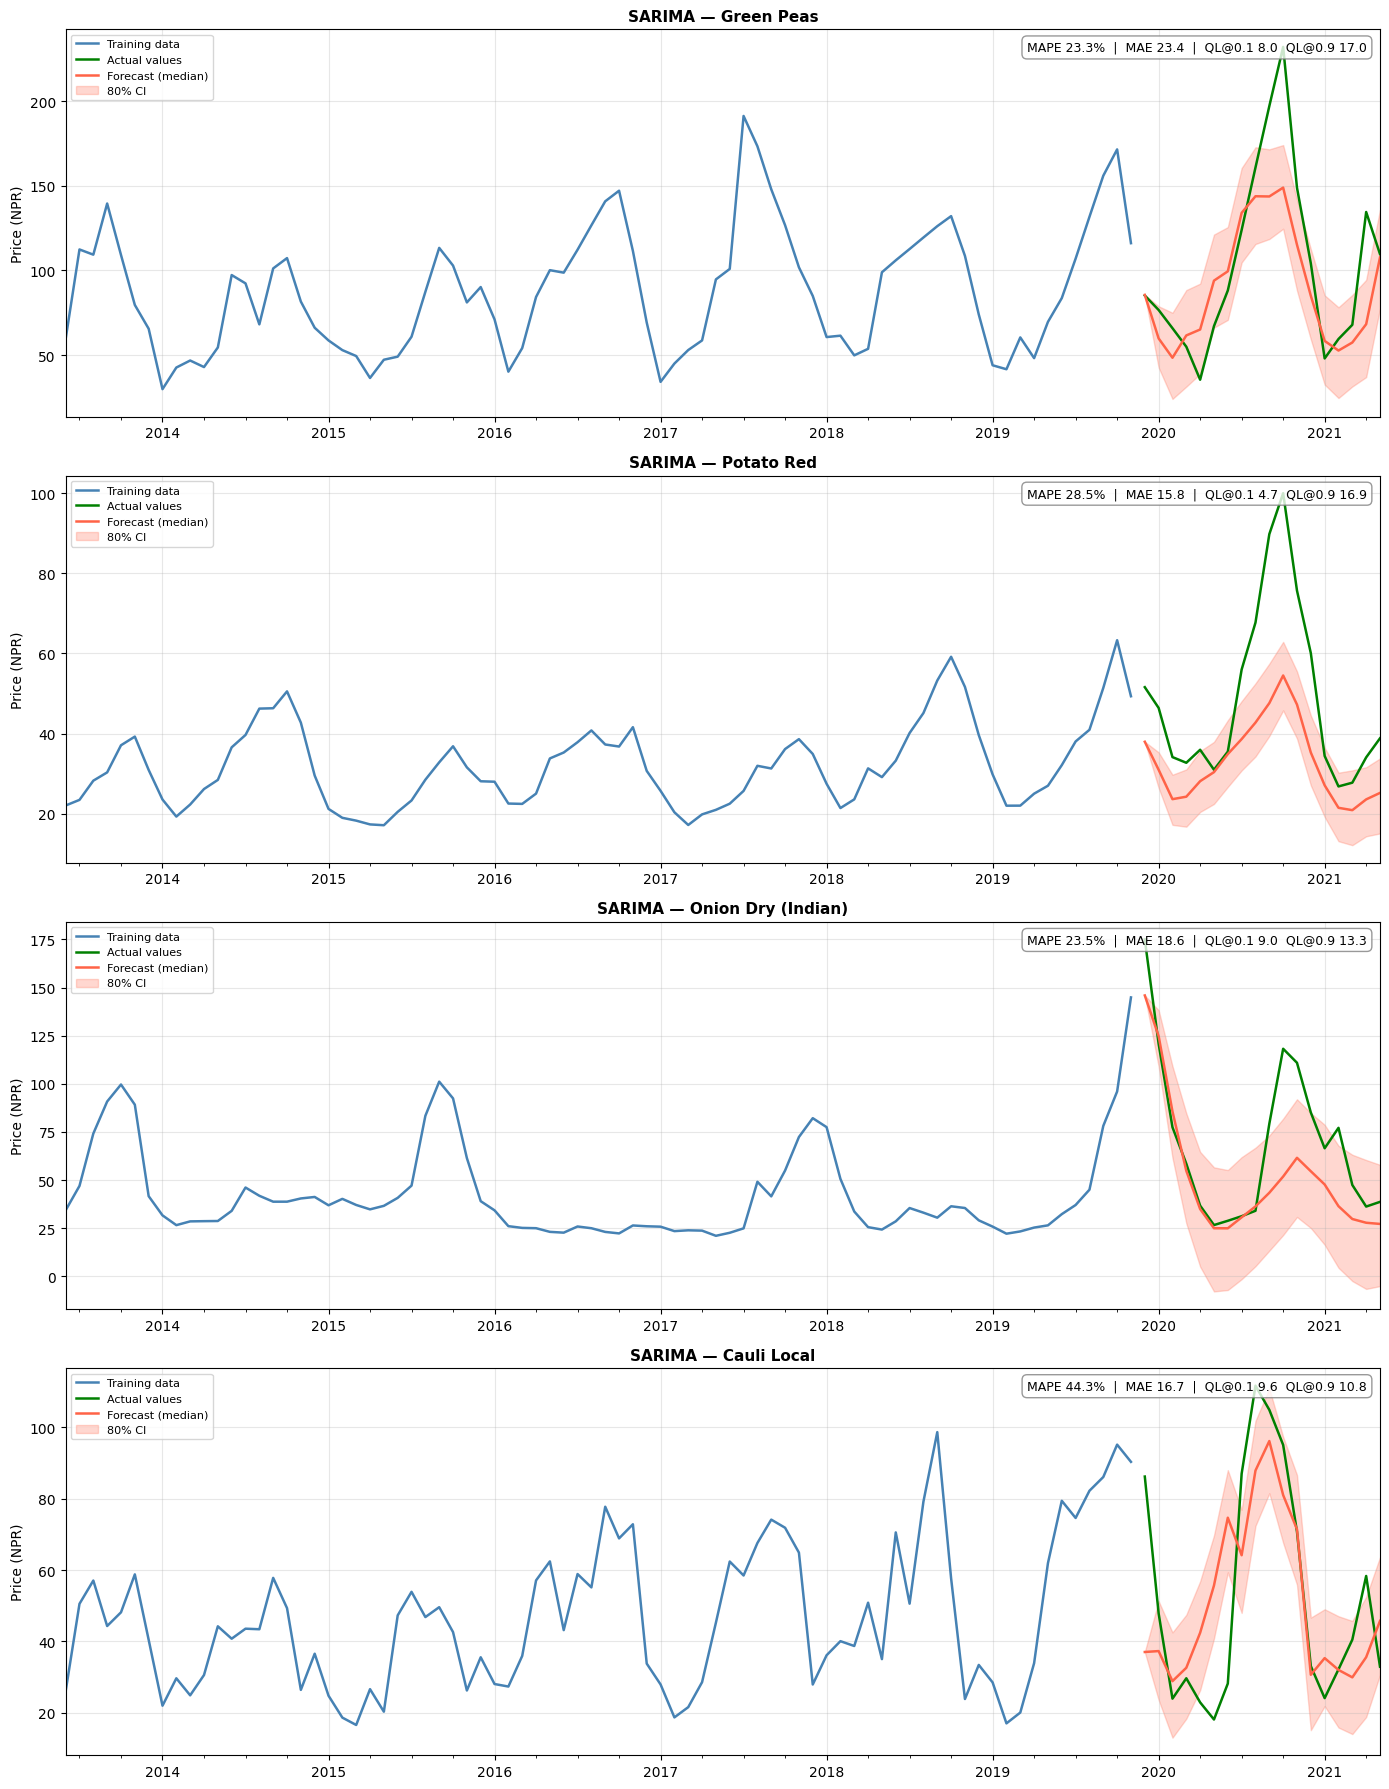

In [106]:
sarima_all_metrics = visualize_multi_forecast("SARIMA", sarima_predictions)

---
## __Model 2: Exponential Smoothing (Holt-Winters)__
### Architecture
The **Holt-Winters** variant (triple exponential smoothing) decomposes the series into **level**, **trend**, and **seasonal** components, each updated recursively with exponentially decaying weights:

| Component | Smoothing Factor | Role |
|-----------|-----------------|------|
| **Level** $\ell_t$ | $\alpha$ | Current baseline, down-weights distant history |
| **Trend** $b_t$ | $\beta$ | Rate of change |
| **Seasonal** $s_t$ | $\gamma$ | Seasonal index at the current cycle position |

Additive forecast: $\hat{y}_{t+h} = \ell_t + h\cdot b_t + s_{t+h-m}$

$\alpha, \beta, \gamma$ are estimated by Maximum Likelihood — you rarely tune them manually.

### Pros ✅ / Cons ❌
✅ Simple, fast, interpretable · handles trend and seasonality · good baseline · robust to outliers
❌ Univariate · constant or proportional seasonal structure · limited non-linearity · long-horizon extrapolation can drift

In [110]:
from darts.models import ExponentialSmoothing
from darts.utils.utils import ModelMode, SeasonalityMode

TREND_MAP    = {"additive": ModelMode.ADDITIVE, "multiplicative": ModelMode.MULTIPLICATIVE, "none": ModelMode.NONE}
SEASONAL_MAP = {"additive": SeasonalityMode.ADDITIVE, "multiplicative": SeasonalityMode.MULTIPLICATIVE}

def es_objective(trial):
    trend_str    = trial.suggest_categorical("trend",    ["additive", "multiplicative", "none"])
    seasonal_str = trial.suggest_categorical("seasonal", ["additive", "multiplicative"])
    damped       = trial.suggest_categorical("damped",   [True, False])
    if trend_str == "none" and damped:
        return float("inf")
    try:
        model = ExponentialSmoothing(
            trend=TREND_MAP[trend_str], seasonal=SEASONAL_MAP[seasonal_str],
            damped=damped, seasonal_periods=12,
        )
        model.fit(ref_train)
        pred = model.predict(n=len(ref_val))
        return mape(ref_val, pred)
    except Exception:
        return float("inf")

study_es = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_es.optimize(es_objective, n_trials=15, show_progress_bar=True)
print(f"\nBest MAPE on '{ref_name}': {study_es.best_value:.2f}%")
print(f"Best params: {study_es.best_params}")

Best trial: 3. Best value: 23.248: 100%|██████████| 15/15 [00:02<00:00,  5.86it/s]


Best MAPE on 'Green Peas': 23.25%
Best params: {'trend': 'none', 'seasonal': 'multiplicative', 'damped': False}


In [111]:
es_predictions = {}
bp = study_es.best_params

for name, train_ts in train_splits.items():
    model = ExponentialSmoothing(
        trend=TREND_MAP[bp["trend"]], seasonal=SEASONAL_MAP[bp["seasonal"]],
        damped=bp["damped"], seasonal_periods=12,
    )
    model.fit(train_ts)
    es_predictions[name] = model.predict(n=TEST_SIZE, num_samples=500)
    print(f"  ✓ {name}")

  ✓ Green Peas
  ✓ Potato Red
  ✓ Onion Dry (Indian)
  ✓ Cauli Local


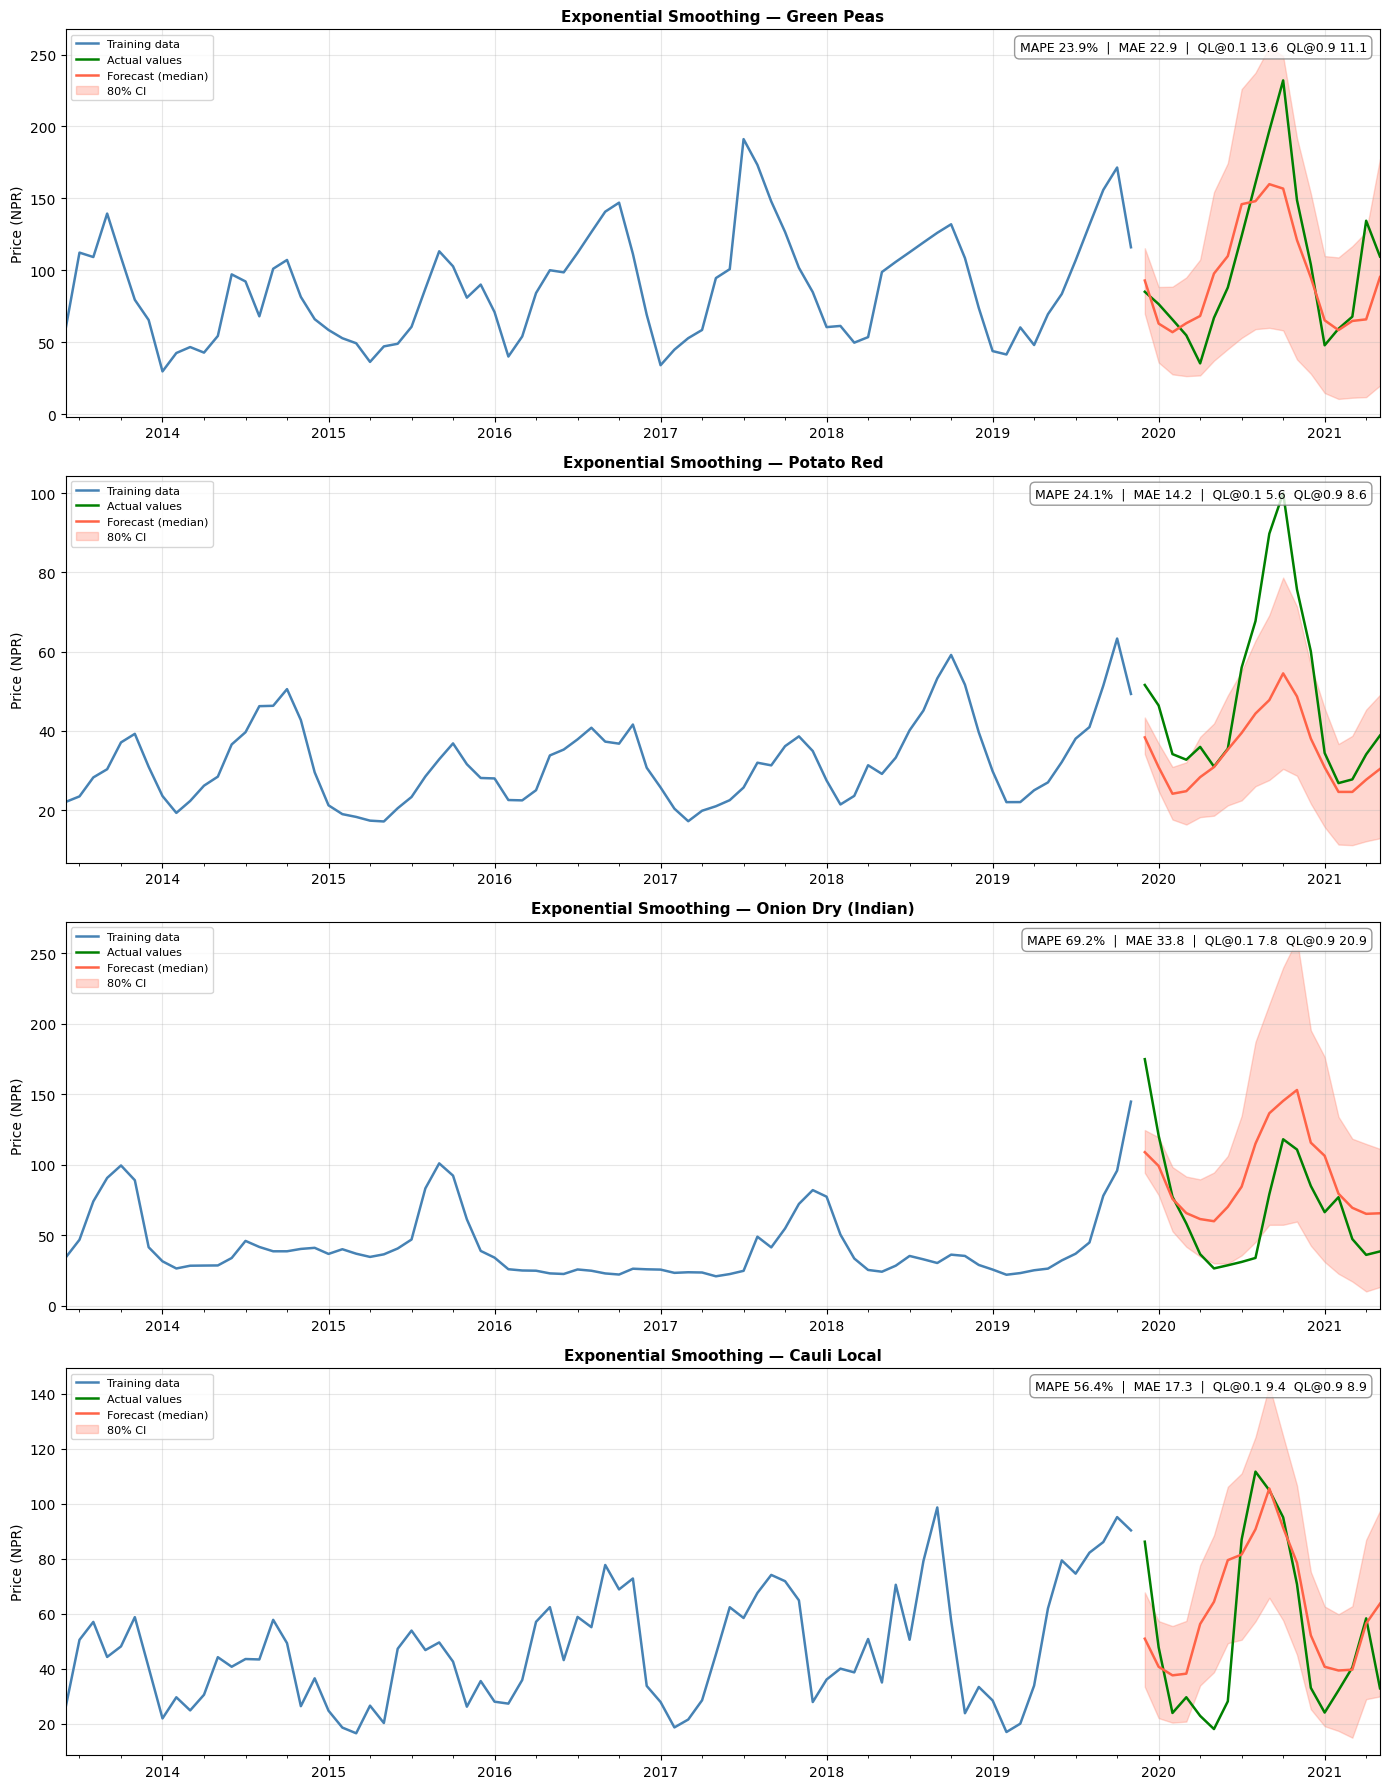

In [112]:
es_all_metrics = visualize_multi_forecast("Exponential Smoothing", es_predictions)

---
## __Model 3: Prophet__
### Architecture
An additive decomposable model developed by Meta, designed for business time series with **multiple seasonalities** and **trend changepoints**:
$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t$$

| Component | Description |
|-----------|-------------|
| $g(t)$ | Trend — piecewise linear or logistic growth; changepoints detected automatically |
| $s(t)$ | Seasonality — Fourier series; handles yearly, weekly, daily simultaneously |
| $h(t)$ | Holidays — user-specified special dates |

### Pros ✅ / Cons ❌
✅ Automatic changepoint detection · multiple seasonalities · robust to missing data and outliers · native uncertainty intervals
❌ Can overfit with too many changepoints · limited multivariate support · less effective on short series

In [113]:
from darts.models import Prophet

def prophet_objective(trial):
    cps = trial.suggest_float("changepoint_prior_scale",  0.001, 0.5,  log=True)
    sps = trial.suggest_float("seasonality_prior_scale",  0.01,  10.0, log=True)
    try:
        model = Prophet(changepoint_prior_scale=cps, seasonality_prior_scale=sps)
        model.fit(ref_train)
        pred = model.predict(n=len(ref_val))
        return mape(ref_val, pred)
    except Exception:
        return float("inf")

study_prophet = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_prophet.optimize(prophet_objective, n_trials=15, show_progress_bar=True)
print(f"\nBest MAPE on '{ref_name}': {study_prophet.best_value:.2f}%")
print(f"Best params: {study_prophet.best_params}")

  0%|          | 0/15 [00:00<?, ?it/s]11:20:40 - cmdstanpy - INFO - Chain [1] start processing
11:20:40 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 24.4588:   7%|▋         | 1/15 [00:00<00:02,  6.66it/s]11:20:40 - cmdstanpy - INFO - Chain [1] start processing
11:20:41 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 1. Best value: 23.0323:  13%|█▎        | 2/15 [00:00<00:03,  3.31it/s]11:20:41 - cmdstanpy - INFO - Chain [1] start processing
11:20:41 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 1. Best value: 23.0323:  20%|██        | 3/15 [00:00<00:02,  4.41it/s]11:20:41 - cmdstanpy - INFO - Chain [1] start processing
11:20:42 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 1. Best value: 23.0323:  27%|██▋       | 4/15 [00:01<00:04,  2.33it/s]11:20:42 - cmdstanpy - INFO - Chain [1] start processing
11:20:42 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 1. Best value: 23.0323:  33%|███▎      | 5/15 [00:01<00:0


Best MAPE on 'Green Peas': 22.22%
Best params: {'changepoint_prior_scale': 0.4137629314336303, 'seasonality_prior_scale': 0.3389960292782601}


In [114]:
prophet_predictions = {}
bp = study_prophet.best_params

for name, train_ts in train_splits.items():
    model = Prophet(
        changepoint_prior_scale=bp["changepoint_prior_scale"],
        seasonality_prior_scale=bp["seasonality_prior_scale"],
    )
    model.fit(train_ts)
    prophet_predictions[name] = model.predict(n=TEST_SIZE, num_samples=500)
    print(f"  ✓ {name}")

11:20:48 - cmdstanpy - INFO - Chain [1] start processing
11:20:48 - cmdstanpy - INFO - Chain [1] done processing
11:20:48 - cmdstanpy - INFO - Chain [1] start processing


  ✓ Green Peas


11:20:48 - cmdstanpy - INFO - Chain [1] done processing
11:20:49 - cmdstanpy - INFO - Chain [1] start processing


  ✓ Potato Red


11:20:49 - cmdstanpy - INFO - Chain [1] done processing
11:20:49 - cmdstanpy - INFO - Chain [1] start processing


  ✓ Onion Dry (Indian)


11:20:49 - cmdstanpy - INFO - Chain [1] done processing


  ✓ Cauli Local


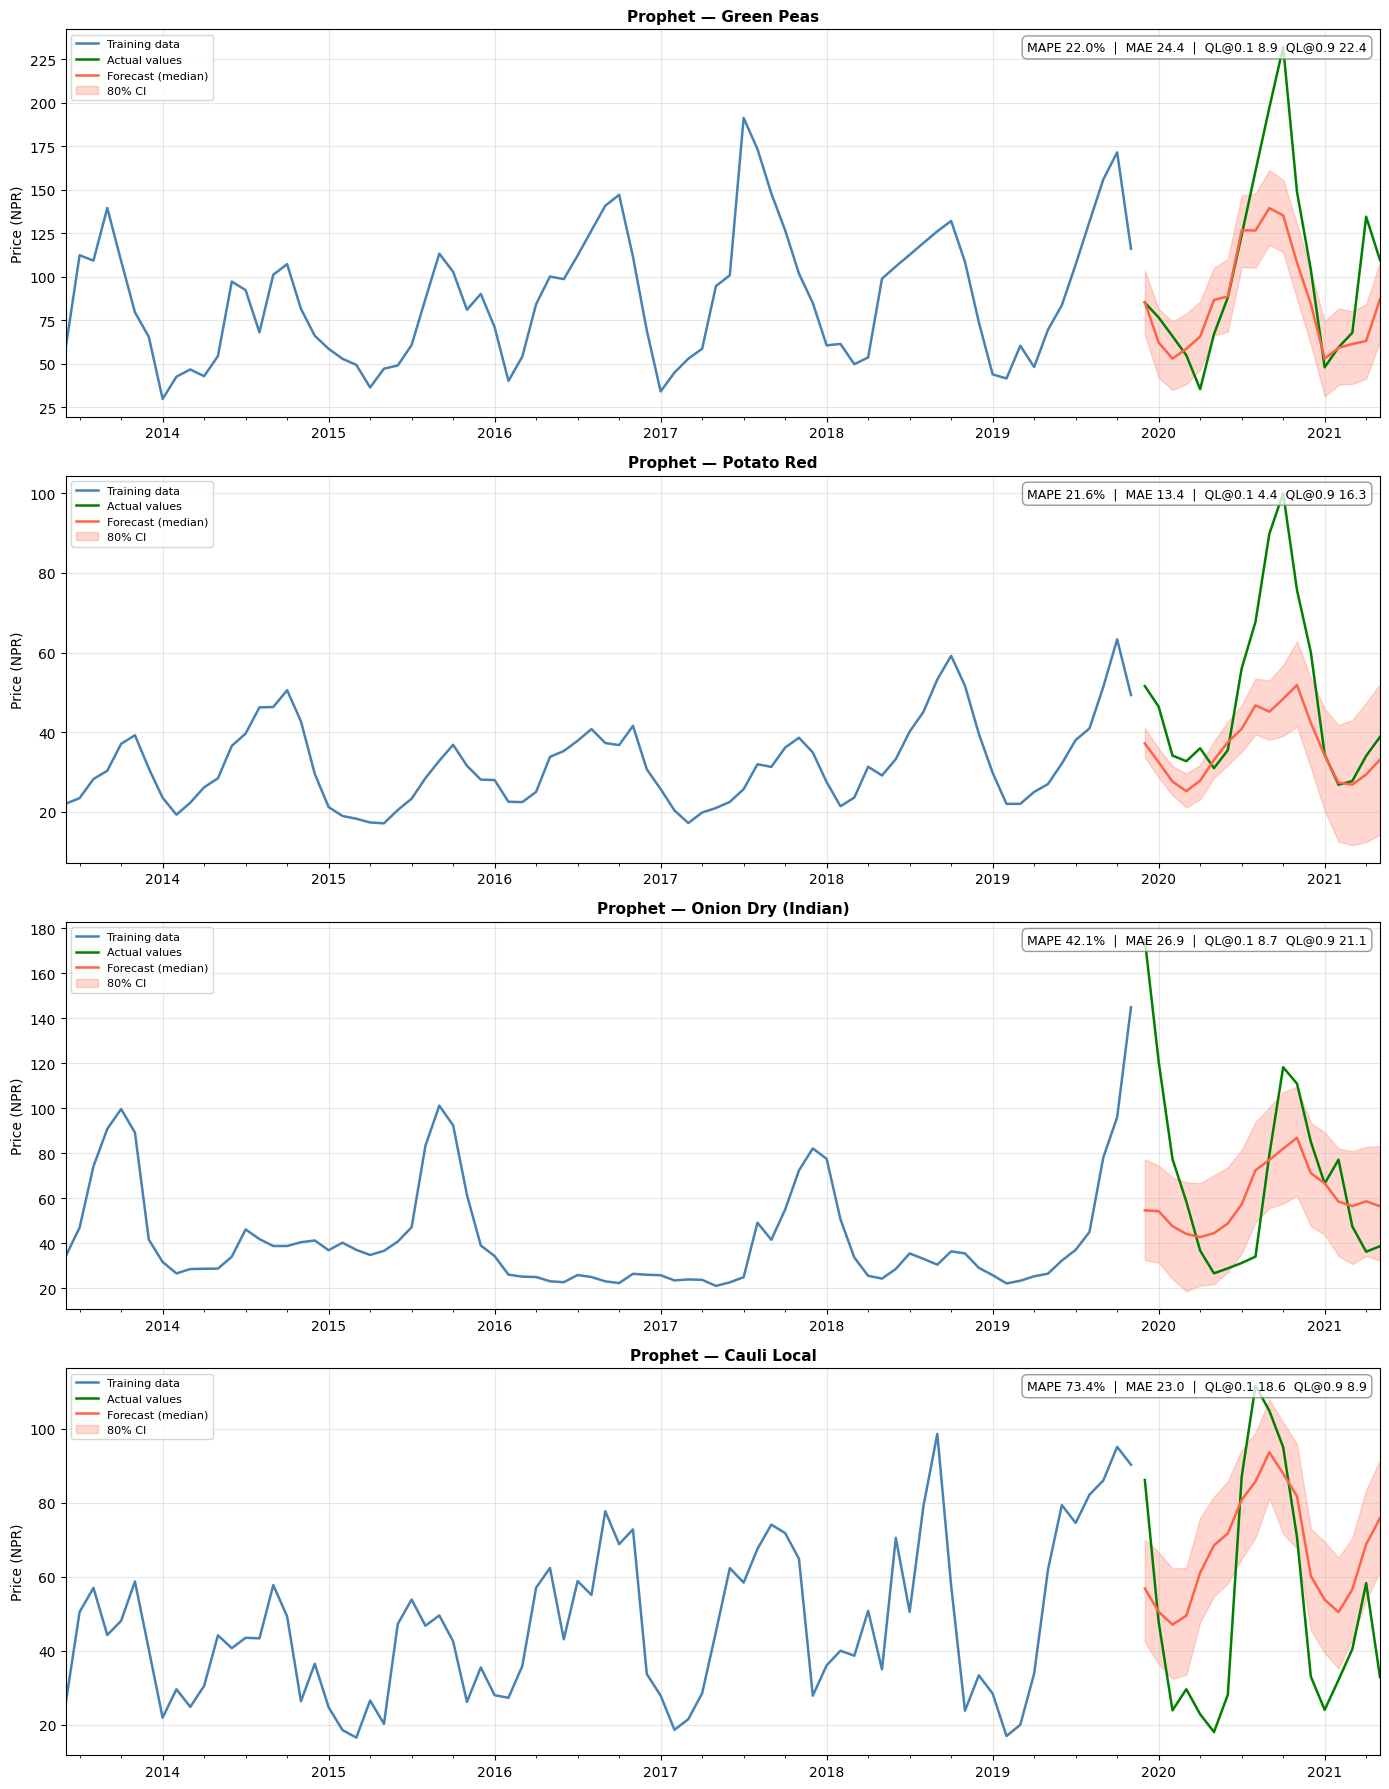

In [115]:
prophet_all_metrics = visualize_multi_forecast("Prophet", prophet_predictions)

---
## __Model 4: XGBoost (Time-Lagged Regression) — Global Model__
### Architecture
XGBoost builds an ensemble of **decision trees** sequentially, with each tree correcting the errors of its predecessors. Applied to time series, the problem is cast as supervised regression:

> Given the last $k$ values $(y_{t-1}, ..., y_{t-k})$, predict $y_t$

These past values are **lag features**. Darts' `XGBModel` creates them automatically via the `lags` parameter.

### Global Training 🌐
Unlike SARIMA or Exponential Smoothing (which train one model per series), `XGBModel` is a **global model**: it is fitted on **all commodity series simultaneously**. The model pools every lag-feature row from every series into one training matrix, learning shared cross-series patterns in a single XGBoost tree ensemble. At inference time, the trained global model is applied individually to each series.

### Pros ✅ / Cons ❌
✅ Captures non-linear lag dependencies · handles external covariates · feature importance available · benefits from cross-series data pooling
❌ Cannot extrapolate beyond training value range · no built-in seasonality · memory-intensive for long lag windows

In [116]:
from darts.models import XGBModel

def xgb_objective(trial):
    lags = trial.suggest_int("lags", 6, 24)
    n_est = trial.suggest_int("n_estimators", 50, 300)
    depth = trial.suggest_int("max_depth", 2, 8)
    lr    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    sub   = trial.suggest_float("subsample", 0.6, 1.0)
    try:
        model = XGBModel(lags=lags, n_estimators=n_est, max_depth=depth,
                         learning_rate=lr, subsample=sub, random_state=42)
        model.fit(ref_train)
        pred = model.predict(n=len(ref_val), series=ref_train)
        return mape(ref_val, pred)
    except Exception:
        return float("inf")

study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=20, show_progress_bar=True)
print(f"\nBest MAPE on '{ref_name}': {study_xgb.best_value:.2f}%")
print(f"Best params: {study_xgb.best_params}")

Best trial: 3. Best value: 22.3049: 100%|██████████| 20/20 [00:01<00:00, 11.03it/s]


Best MAPE on 'Green Peas': 22.30%
Best params: {'lags': 9, 'n_estimators': 126, 'max_depth': 5, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167}


In [140]:
train_splits.keys()

dict_keys(['Green Peas', 'Potato Red', 'Onion Dry (Indian)', 'Cauli Local'])

In [120]:
xgb_predictions = {}
bp = study_xgb.best_params

train_series_list = list(train_splits.values())

global_xgb = XGBModel(
    lags=bp["lags"], n_estimators=bp["n_estimators"], max_depth=bp["max_depth"],
    learning_rate=bp["learning_rate"], subsample=bp["subsample"], random_state=42,
)
global_xgb.fit(train_series_list)   
print(f"Global XGBModel trained on {len(train_series_list)} series")

for name, train_ts in train_splits.items():
    xgb_predictions[name] = global_xgb.predict(n=TEST_SIZE, series=train_ts)
    print(f"  ✓ {name}")

Global XGBModel trained on 4 series
  ✓ Green Peas
  ✓ Potato Red
  ✓ Onion Dry (Indian)
  ✓ Cauli Local


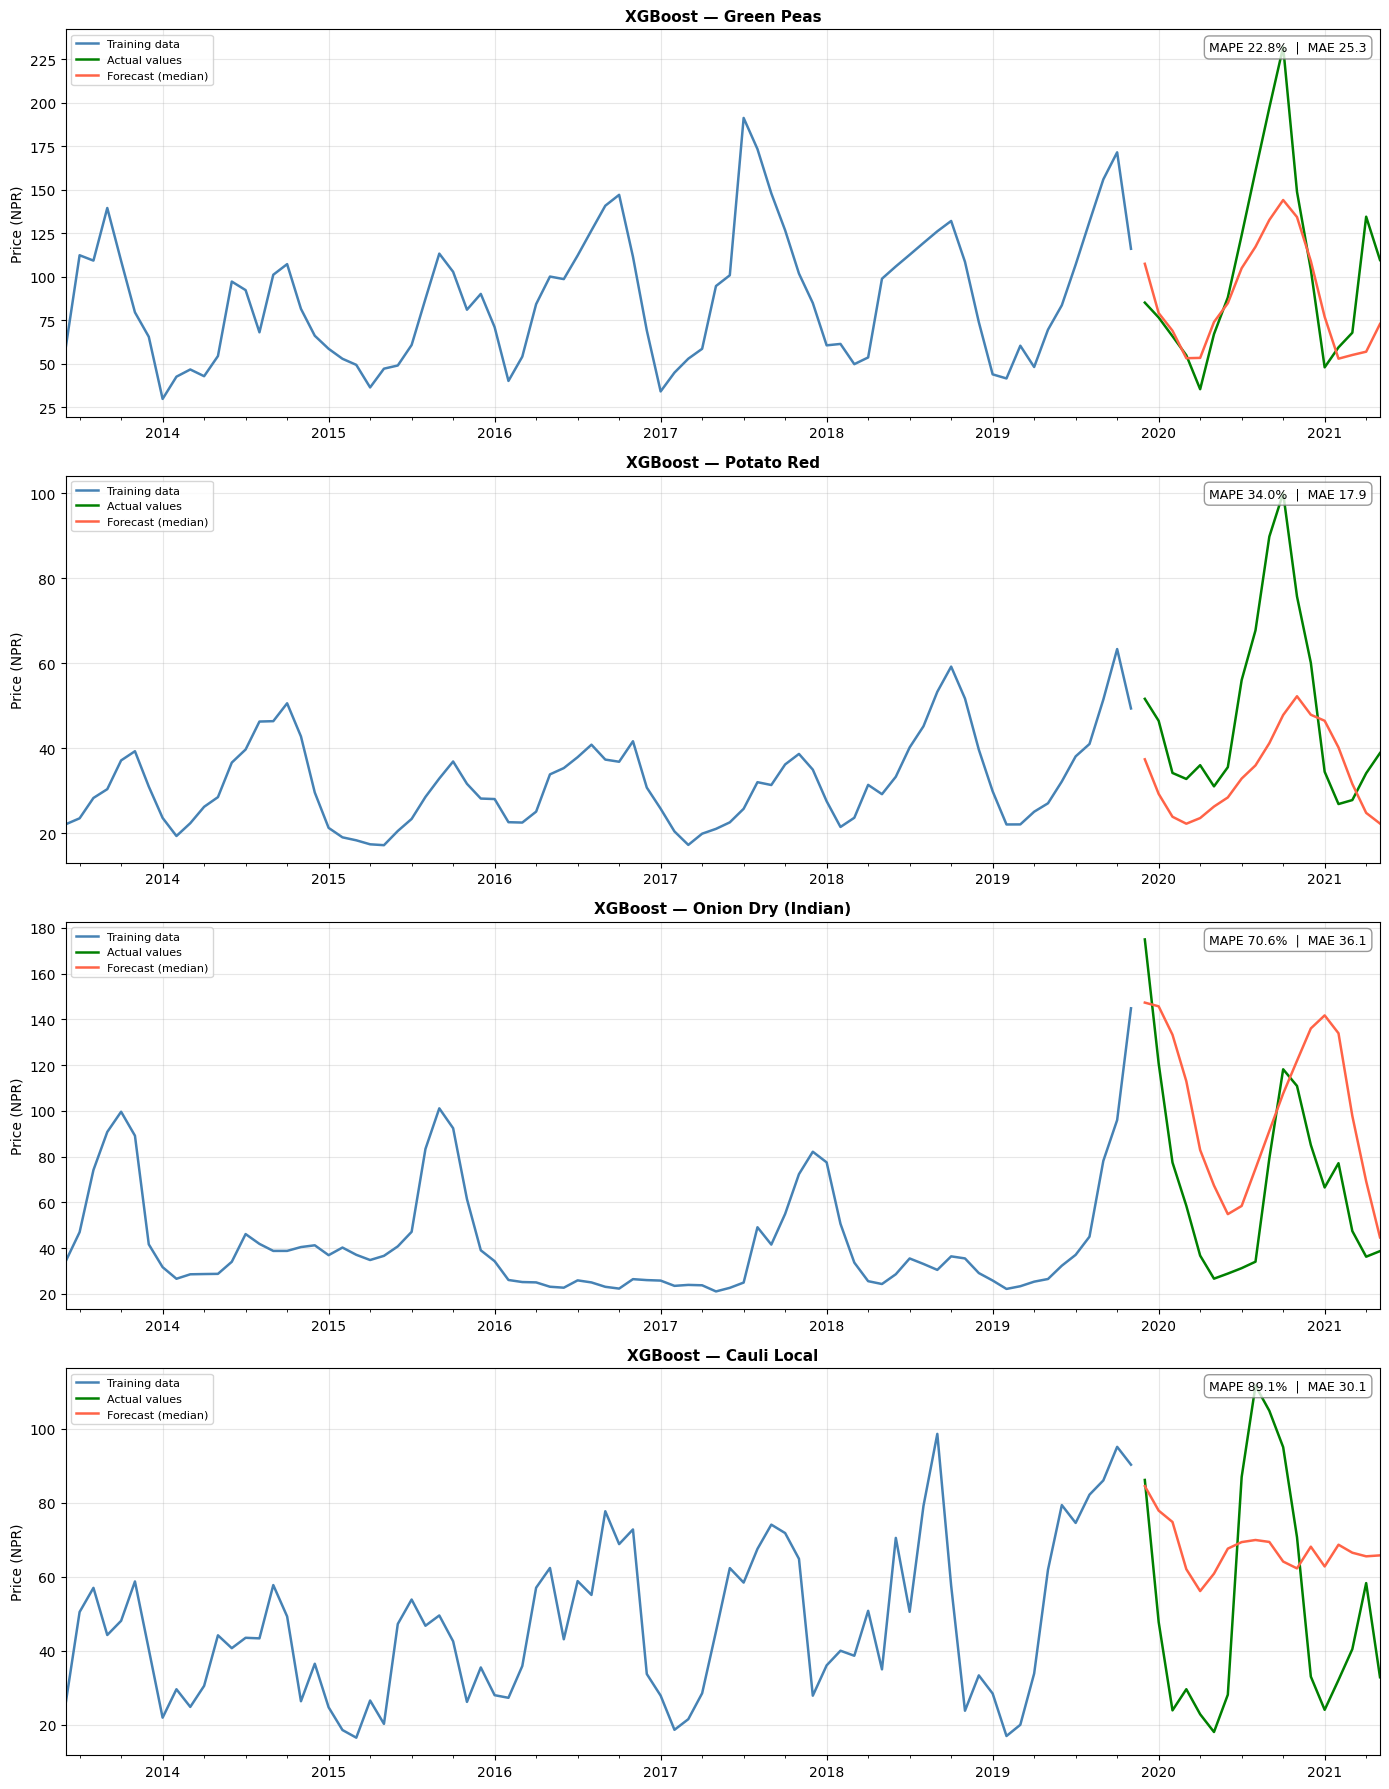

In [121]:
xgb_all_metrics = visualize_multi_forecast("XGBoost", xgb_predictions)

---
## __Model 5: Amazon Chronos2 (Zero-Shot Pretrained Transformer) — Global fit__
### Architecture
A pretrained foundation model from Amazon, trained on ~100 billion time series observations. Requires **no training on your data** — it performs zero-shot forecasting via a **T5 encoder-decoder Transformer**:

1. Historical values are **tokenized** — discretized into vocabulary bins (analogous to word tokens in NLP)
2. The **encoder** processes the tokenized history
3. The **decoder** autoregressively generates future tokens
4. Tokens are **de-tokenized and rescaled** to the original value range

### Pros ✅ / Cons ❌
✅ Zero training required · natively probabilistic (outputs full quantile distributions) · no stationarity assumptions
❌ CPU inference is slow for long contexts · frozen weights (no fine-tuning) · full black box · may underperform specialist tuned models

In [ ]:
from darts.models import Chronos2Model
from darts.utils.likelihood_models.torch import QuantileRegression

chronos_model = Chronos2Model(
    model_name="amazon/chronos-bolt-base",
    input_chunk_length=36,   # ~3 years of monthly context
    output_chunk_length=TEST_SIZE,
    likelihood=QuantileRegression([0.1, 0.5, 0.9])
)

In [134]:
train_series_list = list(train_splits.values())
chronos_model.fit(train_series_list)  
print(f"Chronos fitted on {len(train_series_list)} series (zero-shot, weights unchanged)")

chronos_predictions = {}
for name, train_ts in train_splits.items():
    pred = chronos_model.predict(
        n=TEST_SIZE,
        series=train_ts,
        num_samples=500
    )
    chronos_predictions[name] = pred
    print(f"  ✓ {name}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Chronos fitted on 4 series (zero-shot, weights unchanged)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  ✓ Green Peas


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  ✓ Potato Red


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  ✓ Onion Dry (Indian)


  ✓ Cauli Local


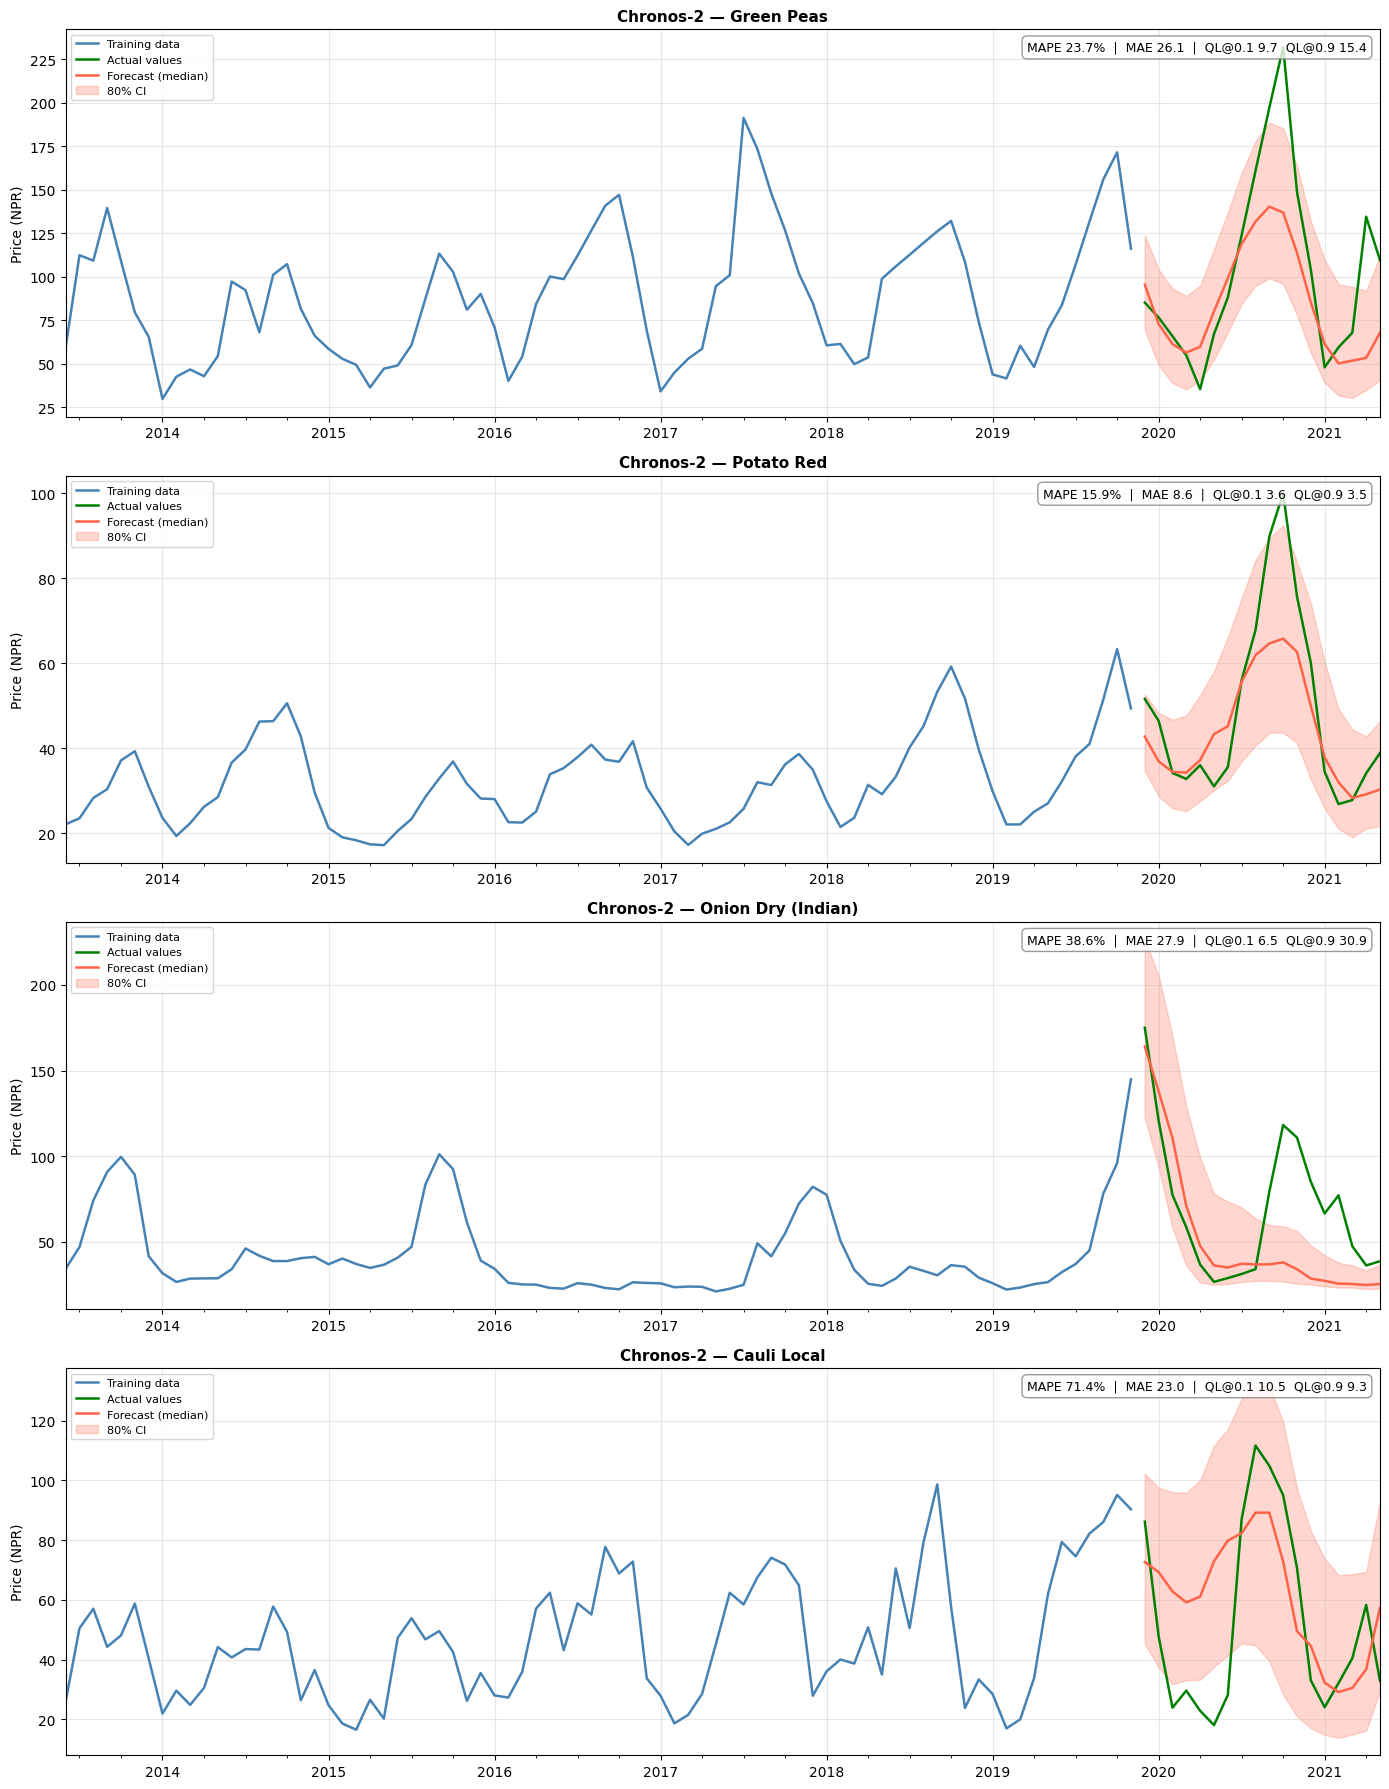

In [135]:
chronos_all_metrics = visualize_multi_forecast("Chronos-2", chronos_predictions)

---
## __Model Comparison__
Summary of all models across all 4 commodities on the 18-month hold-out set.

In [136]:
model_results = {
    "SARIMA":         sarima_all_metrics,
    "Exp. Smoothing": es_all_metrics,
    "Prophet":        prophet_all_metrics,
    "XGBoost":        xgb_all_metrics,
    "Chronos-Bolt":   chronos_all_metrics,
}

rows = []
for model_name, metrics_by_commodity in model_results.items():
    for commodity, m in metrics_by_commodity.items():
        for metric, val in m.items():
            rows.append({"Model": model_name, "Metric": metric, "Commodity": commodity, "Value": val})

results_df = pd.DataFrame(rows)

# Pivot: rows = (Model, Metric), columns = Commodity
pivot = results_df.pivot_table(index=["Model", "Metric"], columns="Commodity", values="Value")
pivot

Commodity                Cauli Local  Green Peas  Onion Dry (Indian)  \
Model          Metric                                                  
Chronos-Bolt   MAE            22.967      26.114              27.929   
               MAPE (%)       71.399      23.701              38.568   
               MSE           737.080    1366.275            1349.291   
               QL@0.1         10.520       9.681               6.525   
               QL@0.9          9.301      15.412              30.867   
Exp. Smoothing MAE            17.264      22.882              33.821   
               MAPE (%)       56.387      23.852              69.189   
               MSE           535.555     924.197            1565.520   
               QL@0.1          9.391      13.592               7.760   
               QL@0.9          8.912      11.060              20.873   
Prophet        MAE            22.998      24.402              26.871   
               MAPE (%)       73.370      21.980              42.103   
               MSE           716.861    1292.346            1458.408   
               QL@0.1         18.582       8.926               8.724   
               QL@0.9          8.874      22.384              21.121   
SARIMA         MAE            16.742      23.408              18.572   
               MAPE (%)       44.342      23.319              23.481   
               MSE           489.494    1037.183             697.172   
               QL@0.1          9.562       8.049               9.035   
               QL@0.9         10.828      16.959              13.280   
XGBoost        MAE            30.084      25.263              36.095   
               MAPE (%)       89.064      22.837              70.562   
               MSE          1070.940    1315.565            1659.079   

Commodity                Potato Red  
Model          Metric                
Chronos-Bolt   MAE            8.592  
               MAPE (%)      15.900  
               MSE          148.080  
               QL@0.1         3.636  
               QL@0.9         3.498  
Exp. Smoothing MAE           14.153  
               MAPE (%)      24.104  
               MSE          368.644  
               QL@0.1         5.636  
               QL@0.9         8.623  
Prophet        MAE           13.357  
               MAPE (%)      21.630  
               MSE          379.574  
               QL@0.1         4.352  
               QL@0.9        16.284  
SARIMA         MAE           15.764  
               MAPE (%)      28.458  
               MSE          404.507  
               QL@0.1         4.668  
               QL@0.9        16.933  
XGBoost        MAE           17.947  
               MAPE (%)      33.951  
               MSE          498.657

In [137]:
mape_df = (
    results_df[results_df["Metric"] == "MAPE (%)"]
    .pivot(index="Model", columns="Commodity", values="Value")
)
mape_df["Mean MAPE"] = mape_df.mean(axis=1)
mape_df = mape_df.sort_values("Mean MAPE")

mape_df.style \
    .background_gradient(cmap="RdYlGn_r", axis=None) \
    .format("{:.2f}") \
    .set_caption("MAPE (%) — lower is better (green)")

Commodity,Cauli Local,Green Peas,Onion Dry (Indian),Potato Red,Mean MAPE
Model,,,,,
SARIMA,44.34,23.32,23.48,28.46,29.90
Chronos-Bolt,71.40,23.70,38.57,15.90,37.39
Prophet,73.37,21.98,42.10,21.63,39.77
Exp. Smoothing,56.39,23.85,69.19,24.10,43.38
XGBoost,89.06,22.84,70.56,33.95,54.10


# __Hometask__

1. Load the **Electricity Consumption data** in Romania (`./datasets/electricity_consumption_and_production.csv`). Use the `Consumption` column as the target variable.
2. Perform **EDA**: decompose the series, plot ACF and PACF, and run the ADF stationarity test. Note that the data contains **hourly observations** — resample to daily before performing forecast.
3. Clean data if necessary.
4. Train forecasting models (Use models from the lecture or other ones if you wish) and produce forecasts for **15, 30, and 45 days ahead**.
5. Visualize predictions and provide evaluation metrics